# The `ASD` Class

The `ASD` class computes the azimuthally averaged surface density profile, $\bar\Sigma(r)$, by integrating the product of the eccentricity kernel $\Phi_e(r, a)$ and the semi-major axis surface density profile $\Sigma_a(a)$. This follows the formalism: 

$$
\bar\Sigma(r) = \frac{1}{\pi} \int_{r/2}^{\infty} \frac{\Sigma_a(a)}{a} \, \Phi_e(r, a) \, da.
$$

After initialising the `ASD` class, the integration can be carried out using two methods:

- `compute_quadvec()`: adaptive method using SciPy’s `quad_vec`, suitable for most eccentricity profiles. Not ideal in complex scenarios as the integration limits are fixed.
- `compute_gl()`: Fast, adaptive Gauss–Legendre quadrature over the defined $r$ values. Has flexible, adaptive integration limits, and built-in "rescue rounds" to smartly integrate difficult points where traditional methods like `quad_vec` would fail and return 0.


The `ASD` class is flexible and works with any combination of $\Sigma_a(a)$ and $\Phi_e(r, a)$, including user-supplied ones.


## Initialising the Class

To initialise the `ASD` class, you must supply a precomputed `Kernel` and `SigmaA` object. These can correspond to **any** valid pair of surface density profile $\Sigma_a(a)$ and kernel function $\Phi_e(r, a)$ — including built-in options and custom user-defined forms.

⚠️ **Important:**  The first argument must be the `Kernel`, and the second must be the `SigmaA`. Reversing the order will result in an error.


In [1]:
from debrispy import SigmaA, UniqueEccentricity, Kernel, ASD
import numpy as np

# Define the SigmaA profile
sigma_a_profile = SigmaA(a_min=1, a_max=4, profile_type='power_law', sigma0=1, power=0.5)

# Define the eccentricity profile and compute the kernel
power_law = UniqueEccentricity(a_min=1, a_max=4, e0=0.5, power=0.7)
kernel = Kernel(eccentricity_profile=power_law, 
                r_min = 0.01, r_max = 5)
kernel.compute()

# Initialise the ASD class
asd = ASD(kernel, sigma_a_profile)

## Computing the ASD with `quadvec`

The `compute_quadvec()` method allows the user to compute the ASD using SciPy’s adaptive vectorised integrator `quad_vec`. This is a robust, paralellised and general-purpose integration method that is well-suited for most use cases, especially when the eccentricity kernel $\Phi_e(r, a)$ varies smoothly.

### Key Features

- **Ease of Use**: Requires only the array of $r$ values over which to evaluate $\bar\Sigma(r)$. No additional setup or tuning is needed.
- **Robustness**: A good first approach for new users or for testing simple, smooth profiles. The method handles standard integration tasks with minimal effort.
- **Tolerances**: Accepts optional relative and absolute tolerances via `tol_rel` and `tol_abs` arguments (default: `1e-8`), which control the precision of the integration.
- **Limitations**: Since `quad_vec` uses fixed integration limits and does not adapt based on the structure of the kernel, it can struggle with highly structured or sharp eccentricity profiles. In such cases, we recommend switching to the more flexible and efficient `compute()` method based on custom Gauss–Legendre quadrature.


While `quadvec` is highly general and stable, it is generally **slower** than the built-in Gauss–Legendre integration implemented in `compute()`, especially when evaluated over a dense $r$ grid. Users working with complex eccentricity distributions or requiring fine control over integration behaviour are encouraged to use `compute()` instead.


### Example 1: Unique Eccentricity Distribution

In this example, we demonstrate how to compute the azimuthally symmetric surface density profile $\bar\Sigma(r)$ using a **unique eccentricity profile**.

We define the following profiles:

- **Semi-major axis surface density**: $\Sigma_a(a) = \left( 1/a \right)^{0.5}$

- **Eccentricity profile**: $e(a) = 0.5 \left( 1/a \right)^{0.7}$

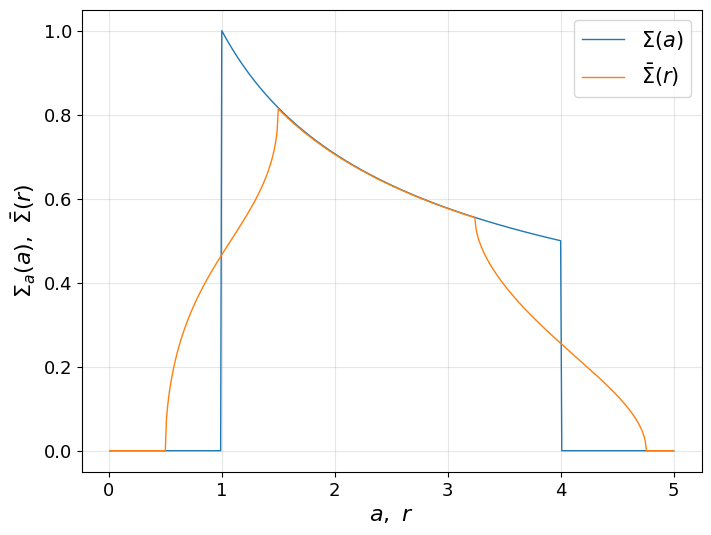

In [2]:
asd.compute_quadvec(r_vals = np.linspace(0.01, 5, 500))
asd.plot(a_vals = np.linspace(0.01, 5, 500))

### Example 2: Rayeleigh Distribution

In this example, we use a **Rayleigh eccentricity distribution**. 

The distribution is governed (see eccentricity section) by a dispersion profile: $ \sigma(a) = 0.4 \cdot \left( 1/a \right)^{0.5} $

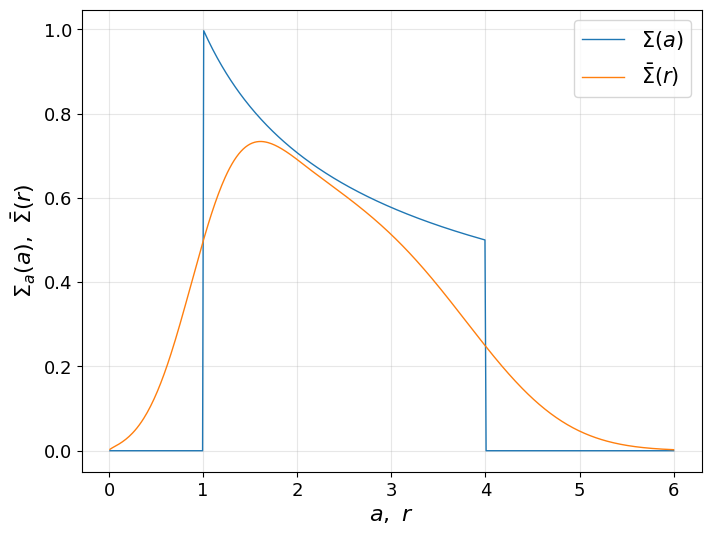

In [4]:
from debrispy import RayleighEccentricity
import debrispy as dp

# Define the SigmaA profile
sigma_a_profile = dp.SigmaA(a_min=1, a_max=4, profile_type='power_law', sigma0=1, power=0.5)

# Define the eccentricity profile and compute the kernel
rayleigh = dp.RayleighEccentricity(a_min=1, a_max=4, sigma0=0.4, power=0.5)
kernel = dp.Kernel(eccentricity_profile=rayleigh, 
                r_min = 0.01, r_max = 6)
kernel.compute()

# Initialise the ASD class
asd = dp.ASD(kernel, sigma_a_profile)

asd.compute_quadvec(r_vals = np.linspace(0.01, 6, 500))
asd.plot(a_vals = np.linspace(0.01, 6, 500))

## Computing the ASD using Adaptive Gauss–Legendre

The `compute_gl()` method offers a robust and flexible way to compute the azimuthally averaged surface density profile, $\bar{\Sigma}(r)$, using **adaptive Gauss–Legendre quadrature**. This method is ideal for complex or sharp eccentricity profiles, especially when `quad_vec` integration fails or becomes inefficient.

Unlike `quadvec`, which is easy to use but has fixed limits and limited control, this method gives the user detailed control over the integration process.

This method has many parameters which can be tuned by the user to strike a balance between computational efficiency and numerical accuracy.

### How It Works

- The method uses recursive adaptive Gauss–Legendre integration over the semi-major axis $a$, at each radius $r$.
- For each $r$, it computes the integrand and integrates over $a$ using a custom-built Gauss–Legendre integrator that supports error control and subdivision. 
- This integration can be parallelised over $r$, and the batch_size and number of jobs (via `joblib`) a tunable parameter.
- When `adaptive_limits=True`, the integration bounds are reduced dynamically to the support region where eccentric particles can reach radius $r$, which can significantly speed up the computation.

### Parameters

| Parameter        | Description |
|------------------|-------------|
| `r_vals`         | Array of radius values $r$ to compute $\bar{\Sigma}(r)$. If `None`, uses 500 evenly spaced points between `kernel.r_min` and `kernel.r_max`. |
| `n_points`       | Number of Gauss–Legendre points per subinterval. Higher values give more accuracy but increase computation time. Default: `64`. |
| `tol_rel`        | Relative tolerance for adaptive integration. Used to trigger subdivision. Default: `1e-8`. |
| `tol_abs`        | Absolute tolerance for adaptive integration. Default: `1e-8`. |
| `max_level`      | Maximum allowed recursion depth (i.e., maximum number of subdivisions per integral). Default: `15`. |
| `n_jobs`         | Number of CPU cores to use. Set to `-1` to use all available cores. Parallelism is used to compute $\bar{\Sigma}(r)$ at multiple $r$ values. |
| `show_progress`  | If `True`, displays a progress bar using `tqdm`. Recommended for long computations. |
| `pad`            | Padding added to adaptive integration bounds, expressed as a fraction of $a$. Default: `0.05`. Used only when `adaptive_limits=True`. |
| `rf` (rescue factor) | Multiplier for `n_points` used when re-evaluating failed integrations during the rescue pass. Default: `5.0`. (See details at the Rescue Pass section below) |
| `adaptive_limits`| If `True`, uses custom integration bounds for each $r$ based on the eccentricity profile. Only supported for unique eccentricity profiles. Can dramatically reduce computation time for narrow support. |
| `batch_size`     | Number of $r$ values to process in each parallel job. Default: `10`. |
| `verbose`        | If `True`, prints diagnostic information, warnings, and progress summaries. |


### Fixed Integration Limits

Firstly, we demonstrate an example (same Rayleigh distribution as above) with **fixed** integration limits. In this case, the integral at every $r$ value is evaluated between `a_min` and `a_max`. This is sufficient for most eccentricity profiles, especially if they are smooth.

Computing ASD with Gauss-Legendre (with fixed limits)...


GL @ 64 pts: 100%|██████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 39.90it/s]


Done. Final result has 500 valid points.



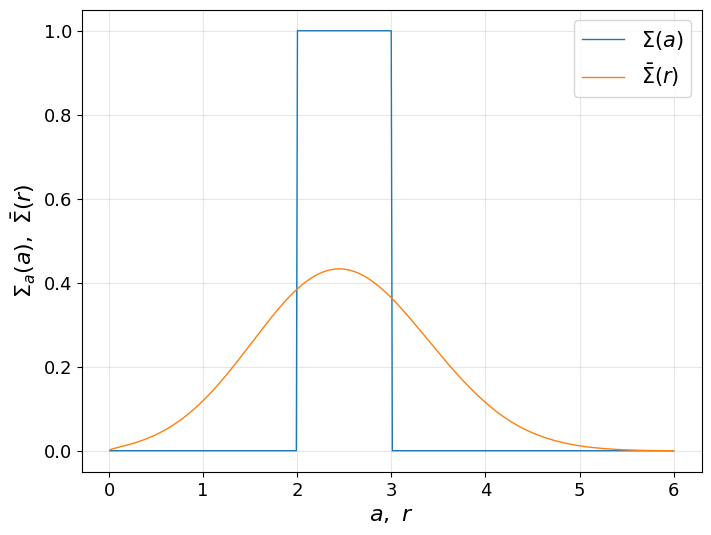

In [5]:
# Define the SigmaA profile
sigma_a_profile = SigmaA(a_min=2, a_max=3, profile_type='power_law', sigma0=1, power=0)

# Define the eccentricity profile and compute the kernel
rayleigh = RayleighEccentricity(a_min=2, a_max=3, sigma0=0.4, power=0.5)
kernel = Kernel(eccentricity_profile=rayleigh, 
                r_min = 0.01, r_max = 6)
kernel.compute()

# Initialise the ASD class
asd = ASD(kernel, sigma_a_profile)

asd.compute_gl(r_vals = np.linspace(0.01, 6, 500), 
               n_points = 64, 
               max_level = 15, 
               n_jobs = 4, 
               show_progress = True, 
               verbose = True)

asd.plot(a_vals = np.linspace(0.01, 6, 500))

### Adaptive Integration Limits

The idea behind adaptive integration limits is to significantly reduce the integration domain for each $r$ value by **identifying the regions of the integrand that actually contribute to the integral.**

For each radius $r$, we compute the corresponding $\kappa = |1 - r/a|$, and determine where the eccentricity profile $e(a)$ satisfies $e(a) > \kappa$. Based on the kernel definition, we know that the integrand is zero outside this region. Therefore, the integration bounds are automatically adjusted to this non-zero domain to improve both **efficiency** and **accuracy**.

This functionality is enabled by setting `adaptive_limits = True`. 

To safeguard against floating point errors or very narrow support, the integration range is slightly extended on both sides using a small padding factor. This is set via `pad=0.05` (default).

Below, we illustrate this mechanism using a periodic eccentricity profile that sharply falls to zero at regular intervals. **Note that this profile is arbitrarily chosen (i.e. not based on physics) to demonstrate how the region with $e(a) > \kappa$ is automatically identified and used as the integration domain.**

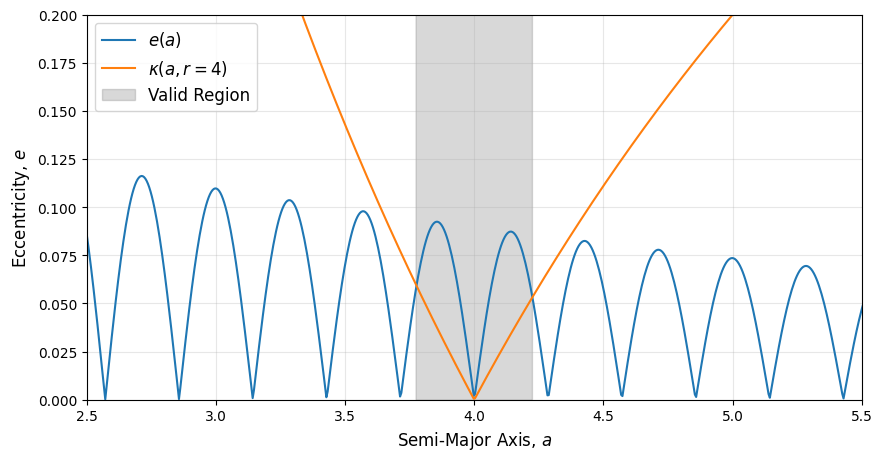

In [6]:
# Demonstration of the 'smart' integration limits
import matplotlib.pyplot as plt

ecc_profile = UniqueEccentricity(a_min=1, a_max=6, eccentricity_func=lambda a: 0.2*np.exp(-a/5)*np.abs(np.sin(a*7*np.pi/2)))
ecc_vals = ecc_profile.eccentricity(a = np.linspace(1, 6, 1000))

def kappa(a, r):
    return np.abs(1 - r/a)


func = ecc_profile.eccentricity(a = np.linspace(1, 6, 1000)) - kappa(np.linspace(1, 6, 1000), 4)
zero_crossings = np.where(np.diff(np.sign(func)))[0]
first_zero = zero_crossings[0]
last_zero = zero_crossings[-1]


plt.figure(figsize=(10, 5))

plt.plot(np.linspace(1, 6, 1000), ecc_vals, label = r'$e(a)$')
plt.plot(np.linspace(1, 6, 1000), kappa(np.linspace(1, 6, 1000), 4), label = r'$\kappa(a, r=4)$')
plt.fill_betweenx(np.linspace(0, 0.2, 1000), 
                  np.linspace(1, 6, 1000)[first_zero], 
                  np.linspace(1, 6, 1000)[last_zero], 
                  color='grey', alpha=0.3, 
                  label = 'Valid Region')

plt.ylim(0, 0.2)
plt.xlim(2.5, 5.5)
plt.grid(alpha = 0.3)
plt.xlabel(r'Semi-Major Axis, $a$', fontsize = 12)
plt.ylabel(r'Eccentricity, $e$', fontsize = 12)
plt.legend(fontsize = 12, loc = 'upper left')
plt.show()

We now compute the ASD via `compute_gl`, setting `adaptive_limits = True`.

Computing ASD with Gauss-Legendre (with adaptive limits)...


GL @ 128 pts: 100%|███████████████████████████████████████████████████████| 100/100 [00:02<00:00, 34.99it/s]


Done. Final result has 1000 valid points.



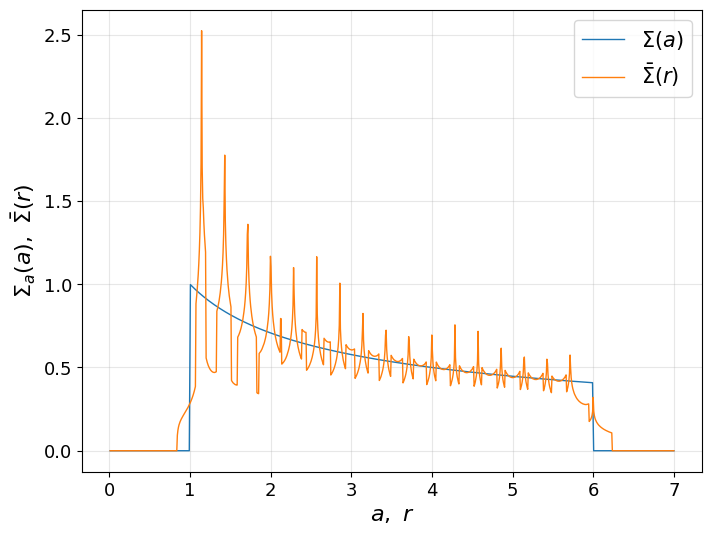

In [7]:
sigma_a_profile = SigmaA(a_min=1, a_max=6, profile_type='power_law', sigma0=1, power=0.5)

# Define the eccentricity profile and compute the kernel
ecc_profile = UniqueEccentricity(a_min=1, a_max=6, eccentricity_func=lambda a: 0.2*np.exp(-a/5)*np.abs(np.sin(a*7*np.pi/2)))

kernel = Kernel(eccentricity_profile=ecc_profile, 
                r_min = 0.01, r_max = 8)
kernel.compute()

asd = ASD(kernel, sigma_a_profile)

asd.compute_gl(r_vals = np.linspace(0.01, 7, 1000), n_points = 128, adaptive_limits = True, show_progress = True, verbose = True)
asd.plot(a_vals = np.linspace(0.01, 7, 500))

### A Note on Rescue Rounds

When working with sharply peaked or narrow eccentricity profiles (especially those that approach zero over most of their domain) the support of the integrand can become **extremely narrow**. In such cases, the Gauss–Legendre integration may fail to resolve the region of non-zero contribution if the number of points (`n_points`) is too small. This is particularly common when using moderate values such as `n_points=64`.

To mitigate this, the ASD class includes a **rescue mechanism** that attempts to detect and correct such failures:

- During the integration, we monitor for *suspicious zero values* in the output $\bar{\Sigma}(r)$. These are defined as **isolated zeros**, i.e., grid points where the result is zero but neighbouring $r$ values are clearly non-zero.
- If such a point is detected, it is flagged for a **rescue round**, where the integration is redone **only for that point**, using an increased number of quadrature points:
  
  $$
  n_{\mathrm{rescue}} = n_\mathrm{points} \times \mathrm{rf}
  $$
  
  where `rf` is the **rescue factor**, defaulting to `5.0`.

After this round, if any suspicious points still remain, we check the **adaptive integration bounds**:

- If *no region* was found where $e(a) > \kappa$, we silently ignore the point. This corresponds to an infinitesimally narrow dip in surface density, which is not representable on a finite $r$ grid.
- If a valid integration region *was* found but the integral still returns zero, a **warning** is printed, suggesting the user try a higher `rf` value or manually inspect the eccentricity profile.

This mechanism helps stabilise the integration in difficult regions without compromising performance across the full $r$ range. For typical use, the default `rf=5.0` is sufficient.

## Refining the $\bar\Sigma(r)$ Grid

For disc profiles with **very narrow features**, a uniform $r$-grid may require a large number of points to resolve them accurately. Instead, we provide an adaptive **curvature-based refinement** method, which sequentially inserts points in regions of high variation in $\bar\Sigma(r)$.

This is done using the `refine()` method.

### How it Works

1. Starting from an initial $\bar\Sigma(r)$ grid, the code computes a **second finite difference (curvature)**.
2. If the curvature at a point exceeds a user-defined threshold, the region is flagged.
3. New $r$-values are inserted between the flagged points and their neighbours.
4. These new points are integrated using Gauss-Legendre quadrature.
5. The process repeats up to `max_rounds` times.

This results in a much more efficient allocation of grid points, concentrating them where $\bar\Sigma(r)$ changes the most.


### Parameters

| Parameter            | Description |
|----------------------|-------------|
| `curvature_factor`   | Multiplier used to determine the curvature threshold. A higher value leads to fewer points being added. Default: `1.0`. |
| `max_rounds`         | Maximum number of refinement rounds to perform. Default: `3`. |
| `subdiv`             | Number of subdivisions to insert between flagged $r$ values. `subdiv=2` adds one midpoint between each flagged pair. |
| `n_jobs`             | Number of CPU cores to use. `-1` uses all available cores. |
| `show_progress`      | If `True`, displays a progress bar during integration. |
| `n_points`           | Number of Gauss–Legendre points per integration interval. Default: `64`. |
| `tol_rel`            | Relative tolerance for the Gauss–Legendre integrator. Default: `1e-8`. |
| `tol_abs`            | Absolute tolerance. Default: `1e-8`. |
| `max_level`          | Maximum recursion depth for adaptive integration. Default: `25`. |
| `adaptive_limits`    | If `True`, computes integration limits locally based on the eccentricity profile. Only supported for `UniqueEccentricity`. |
| `rf` *(rescue factor)* | Factor by which `n_points` is multiplied during the rescue pass. Used to re-integrate suspicious zero points. Default: `10.0`. |
| `pad`                | Padding applied to adaptive integration bounds (as a fraction of $a$). Default: `0.05`. |
| `batch_size`         | Number of $r$ values per parallel batch. Default: `10`. |



- This method **only works with `UniqueEccentricity` profiles**.
- To run the refinement round, the user must first do an initial computation of the ASD (low resolution) using their chosen method.

An example can be seen above, where we first compute $\bar\Sigma(r)$ for a low-resolution grid, and then refine it.

Computing ASD with Gauss-Legendre (with adaptive limits)...


GL @ 128 pts: 100%|████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 297.62it/s]


Done. Final result has 200 valid points.



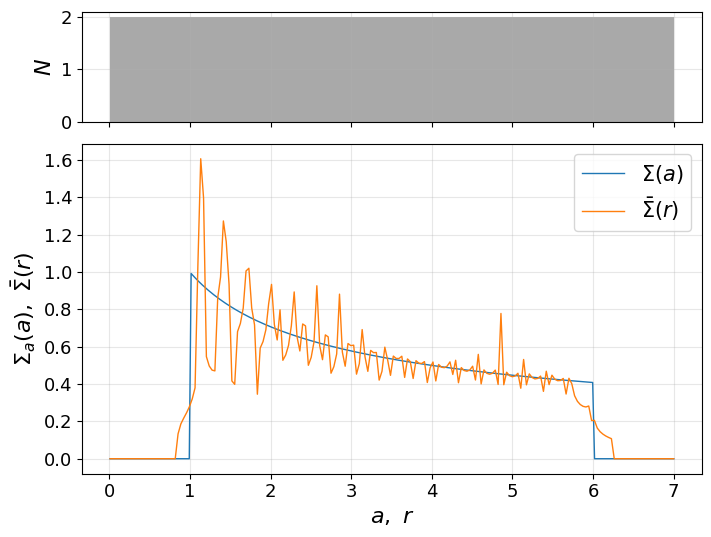

In [8]:
sigma_a_profile = SigmaA(a_min=1, a_max=6, profile_type='power_law', sigma0=1, power=0.5)

# Define the eccentricity profile and compute the kernel
ecc_profile = UniqueEccentricity(a_min=1, a_max=6, eccentricity_func=lambda a: 0.2*np.exp(-a/5)*np.abs(np.sin(a*7*np.pi/2)))

kernel = Kernel(eccentricity_profile=ecc_profile, 
                r_min = 0.01, r_max = 8)
kernel.compute()

asd = ASD(kernel, sigma_a_profile)

asd.compute_gl(r_vals = np.linspace(0.01, 7, 200), n_points = 128, adaptive_limits = True, show_progress = True, verbose = True)
asd.plot(a_vals = np.linspace(0.01, 7, 300), grid_hist = True)

Now applying the grid refinement (the histogram above displays the concentration of grid points at sharp regions):

---- Refining Round 1/3 ----
Added 131 points.
---- Refining Round 2/3 ----
Added 187 points.
---- Refining Round 3/3 ----
Added 231 points.


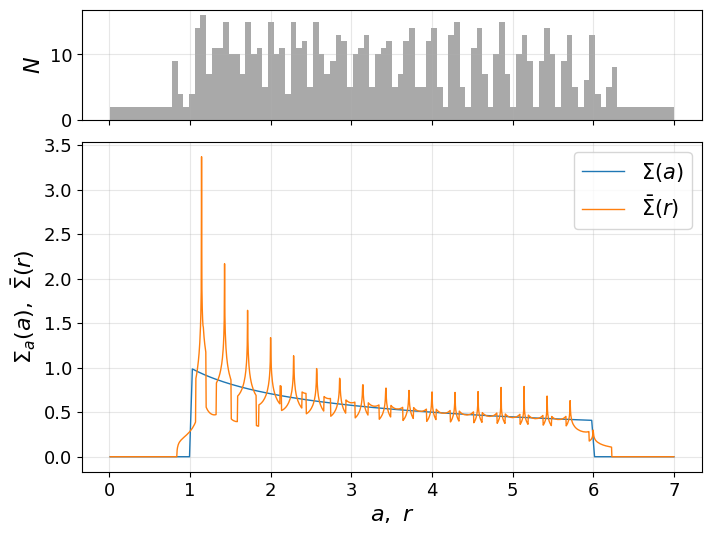

In [9]:
asd.refine(curvature_factor = 1, max_rounds = 3, subdiv=2, rf=5.0, batch_size = 10, n_jobs = -1, adaptive_limits = True)
asd.plot(a_vals = np.linspace(0.01, 7, 200), grid_hist = True)

## Additional Functionality

### Obtaining $\bar\Sigma(r)$ Values

Once the ASD has been computed using any given method, the results can be retrieved using the `get_values()` method.

This returns two arrays:
- The array of radius values, $r$.
- The corresponding surface density values, $\bar\Sigma(r)$.

If the ASD has not yet been computed, this method will raise an error to ensure users don’t accidentally access uninitialised results.

In [10]:
r_vals, sigma_r_vals = asd.get_values()

### Convolution

After computing the ASD, users may apply a Gaussian convolution using the `convolve()` method. This is particularly useful when comparing theoretical predictions to observations, which often have finite resolution.

#### Parameters

- `width` (float): The width of the Gaussian kernel (in the same units as $r$) to smooth the ASD.
- `M` (int, default: 2048): Number of points used for interpolation if the $r$-grid is non-uniform.


If the $r$ grid is uniform, the method applies `scipy.ndimage.gaussian_filter1d` directly.

If the $r$ grid is non-uniform, the method interpolates the ASD to a uniform grid, performs the convolution, and then interpolates the result back to the original $r$ grid.

> Note: Any minor uncertainty introduced by interpolation in the non-uniform case is effectively cancelled out by the subsequent Gaussian blur.

The smoothed values are cached as `self._sigma_r_conv`, and always correspond to the last calculated ASD profile (i.e., the output of the most recent `compute()` or `refine()` call).

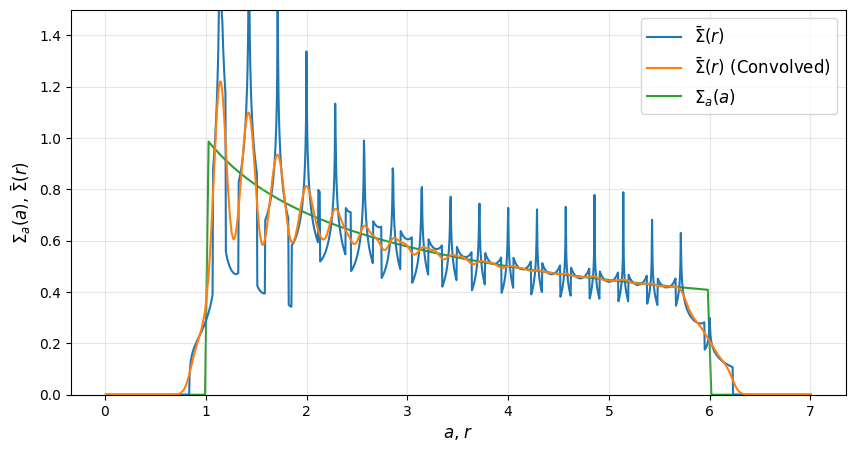

In [11]:
convolved_values = asd.convolve(width = 0.05)

plt.figure(figsize=(10, 5))
plt.plot(r_vals, sigma_r_vals, label = r'$\bar\Sigma(r)$')
plt.plot(r_vals, convolved_values, label = r'$\bar\Sigma(r)$ (Convolved)')
plt.plot(np.linspace(0.01, 7, 200), sigma_a_profile(np.linspace(0.01, 7, 200)), label = r'$\Sigma_a(a)$', zorder = 0)
plt.ylim(0, 1.5)
plt.legend(fontsize = 12, loc = 'upper right')
plt.xlabel(r'$a$, $r$', fontsize = 12)
plt.ylabel(r'$\Sigma_a(a)$, $\bar\Sigma(r)$', fontsize = 12)
plt.grid(alpha = 0.3)
plt.show()

### Plotting Tools

#### Plot Integrand

The `plot_integrand()` method visualises the 2D integrand used in the ASD calculation.

This is useful for diagnosing sharp features, verifying where the function is concentrated, or identifying integration issues. It provides a clear overview of the support and structure of the integrand across $a$ and $r$.

The plotting parameters include:

| Parameter     | Description |
|---------------|-------------|
| `a_vals`      | Optional array of semi-major axis values to evaluate the integrand over. If `None`, uses a default linspace. |
| `r_vals`      | Optional array of radius values to evaluate the integrand over. If `None`, uses a default linspace. |
| `save`        | If `True`, saves the plot to disk. Requires `filename`. |
| `filename`    | Path to save the plot. Must be provided if `save=True`. |
| `vmin`        | Minimum value for the colour scale. If `None`, uses the minimum non-zero value of the data. |
| `vmax`        | Maximum value for the colour scale. If `None`, uses the maximum value of the data. |
| `log`         | If `True`, applies logarithmic colour scaling (ignoring non-positive values). Default is `True`. |
| `cmap`        | Colormap to use (default: `"viridis"`). |
| `colorbar`    | Whether to display a colourbar alongside the plot. Default is `True`. |
| `r_lim`       | Tuple specifying x-axis (radius) limits. |
| `a_lim`       | Tuple specifying y-axis (semi-major axis) limits. |
| `**imshow_kwargs` | Additional keyword arguments passed directly to `imshow()`. |

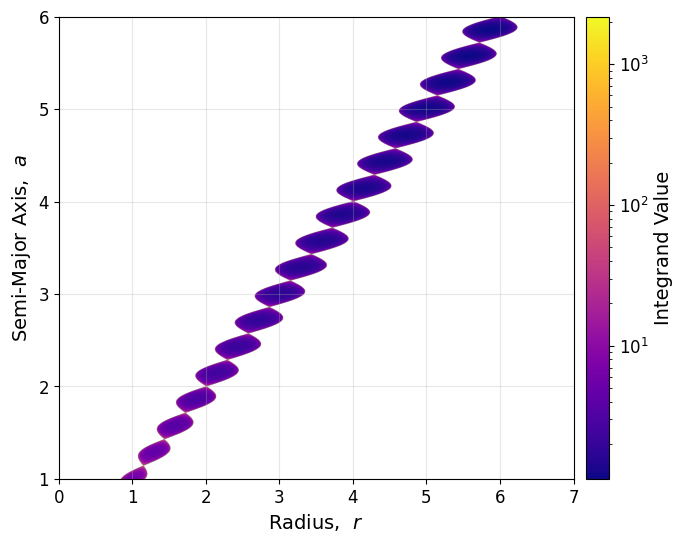

In [12]:
asd.plot_integrand(a_vals = np.linspace(1, 6, 2000),
                   r_vals = np.linspace(0.01, 7, 2000),
                   log=True, cmap="plasma", r_lim=(0, 7), a_lim=(1, 6))

#### Plotting the Surface Densities

The `plot()` is the main plotting tool to visualise the ASD after it has been computed. It can optionally overlay the $\Sigma_a(a)$ profile if desired. Additionally, it optionally overlays a histogram showing how the $r$ grid points are distributed, which can be useful when grid refinement is used.

Parameters include:

| Parameter   | Description |
|-------------|-------------|
| `a_vals`    | Array of semi-major axis values at which to evaluate $\Sigma(a)$. |
| `plot_a`    | If `True` (default), includes the $\Sigma(a)$ profile in the plot. |
| `x_lim`     | Optional tuple specifying the x-axis limits for the plot. |
| `y_lim`     | Optional tuple specifying the y-axis limits for the plot. |
| `save`      | If `True`, saves the plot to disk. Requires `filename`. Default is `False`. |
| `filename`  | Name of the file to save the plot to. Required if `save=True`. |
| `title`     | Optional string to display as the plot title. |
| `grid_hist` | If `True`, adds a histogram of the $r$ grid point distribution above the plot. Useful to check refinement behaviour. Default is `False`. |

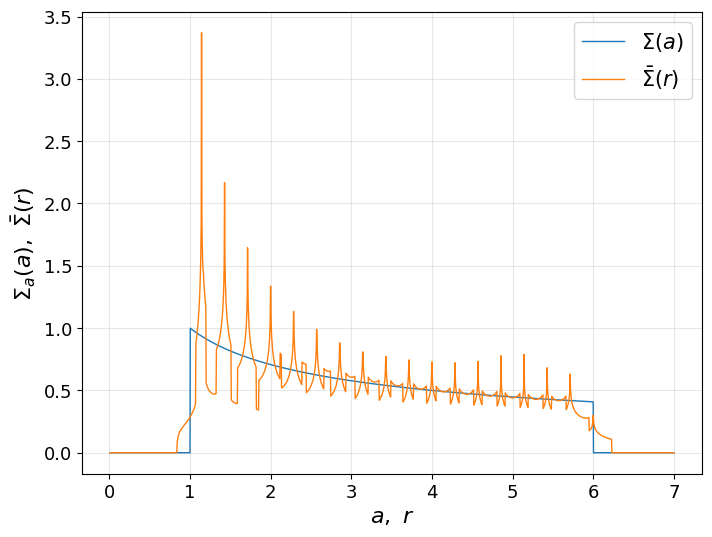

In [13]:
asd.plot(a_vals = np.linspace(0.01, 7, 2000), plot_a = True)

### Plotting the Convolved Profile

The `plot_convolution` method displays the azimuthally averaged surface density profile $\bar\Sigma(r)$ after applying a Gaussian convolution. This is useful for simulating instrumental resolution effects or smoothing out numerical artefacts. Optionally, the original (unconvolved) profile and the input semi-major axis profile $\Sigma(a)$ can also be overlaid for comparison.

This method uses the result of the last call to `convolve()`. If that has not been called yet, the user must specify `width` (the Gaussian kernel width) and optionally `M` (the number of uniform points used in convolution).

#### Parameters

| Parameter             | Description |
|-----------------------|-------------|
| `width`               | Optional float. The Gaussian kernel width used for smoothing (in the same units as $r$). Required if `convolve()` has not already been called. |
| `M`                   | Optional int. Number of uniformly spaced points used for convolution when the $r$-grid is non-uniform. Required if `convolve()` has not already been called. |
| `overlay_sigma_r`     | If `True` (default), overlays the original $\bar\Sigma(r)$ profile for comparison. |
| `overlay_sigma_a`     | If `True`, overlays the semi-major axis profile $\Sigma(a)$ (evaluated over the kernel domain). |
| `x_lim`               | Optional tuple specifying the x-axis limits. |
| `y_lim`               | Optional tuple specifying the y-axis limits. |
| `save`                | If `True`, saves the figure to disk. Requires `filename` to be set. |
| `filename`            | Optional string. Path to save the plot if `save=True`. |
| `title`               | Optional title for the figure. |

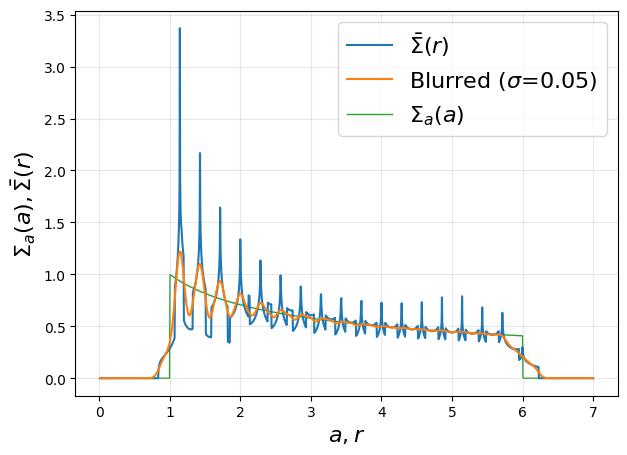

In [14]:
asd.plot_convolution(overlay_sigma_r = True, overlay_sigma_a = True)